In questo notebook si vogliono valutare le performance del sistema.
Per fare ciò viene utilizzato il dataset MemeCap, che contiene immagini e didascalie associate prodotte da esseri umani assunti tramite Amazon Mechanical Turk.
Verrà effettuato il sampling di n=100 meme dal dataset.
Per questi meme verrà calcolata la similarità tra gli embedding delle didascalie generate dal LLM e gli embedding di quelle generate dagli esseri umani.
La similarità verrà calcolata tramite la cosine similarity.

In [1]:
import json

data= json.load(open("memecap_dataset\meme-cap\data\memes-test.json"))
print(len(data))

559


In [2]:
print (data[0].keys())  

dict_keys(['category', 'img_captions', 'meme_captions', 'title', 'url', 'img_fname', 'metaphors', 'post_id'])


In [3]:
data = data[:100]

In [4]:
# 1. Calcolo gli embedding
def join_text_fields (meme_entry):
    text=", ".join(meme_entry["img_captions"])+ ", ".join(meme_entry["meme_captions"])
    return text

from meme_analysis_pipeline.components.local_components import ClipEmbedder
clip_embedder = ClipEmbedder()
for meme_entry in data:
    meme_entry["text"]=join_text_fields(meme_entry)
    meme_entry["clip_embedding"]=clip_embedder.calculate_text_embedding(meme_entry["text"])


d:\Desktop\Git\hypermeme\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
d:\Desktop\Git\hypermeme\meme_analysis_pipeline\components\local_components.py:62: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), torch.cuda.amp.autocast():
d:\Desktop\Git\hypermeme\.venv\Lib\site-packages\torch\amp\autocast_mode.py:266: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(


In [5]:
data[0]["clip_embedding"].squeeze(0).detach().numpy()

array([-3.79112005e-01,  2.11193189e-02,  3.96901071e-01,  1.65675849e-01,
       -1.92016467e-01, -4.68229592e-01,  7.79855251e-02,  5.82372770e-02,
        2.41220310e-01, -3.59543920e-01, -1.58124447e-01, -3.67135257e-02,
        1.40303060e-01,  2.69229084e-01, -5.10769129e-01, -2.74285883e-01,
       -1.51590854e-02, -4.62456346e-02,  1.80592820e-01, -5.00097156e-01,
        2.72489935e-02,  1.45147353e-01,  2.33488649e-01, -2.02964753e-01,
       -5.02552807e-01, -1.70908421e-01, -1.91287354e-01, -2.40987390e-02,
       -2.04620898e-01,  3.97891998e-01, -4.29452807e-01, -5.98638579e-02,
       -1.47818446e-01,  3.05003703e-01,  3.44616979e-01, -2.48944182e-02,
       -6.56902343e-02,  9.67016071e-02,  8.74862820e-03, -1.41203880e-01,
        4.10529703e-01,  2.40208562e-02, -3.86336595e-02, -1.61545575e-02,
       -1.59031570e-01, -2.08740085e-02, -2.01421142e-01,  7.55000263e-02,
        4.75924090e-02,  1.07690036e-01,  1.34598345e-01,  5.74800134e-01,
        2.77734399e-01,  

In [ ]:
%store -r df

In [37]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import pandas as pd

def calculate_and_show_similarity (first, second, legend):
    similarity_matrix = cosine_similarity (first, second)
    similarity_array= np.diag(similarity_matrix)
    print (legend, " mean ", similarity_array.mean())
    print (legend, " std ", similarity_array.std())
    sdf= pd.DataFrame(similarity_array)
    # sdf.hist()
    sdf.boxplot()
    return similarity_array

human_text_llm_text  mean  0.61617506
human_text_llm_text  std  0.09520531


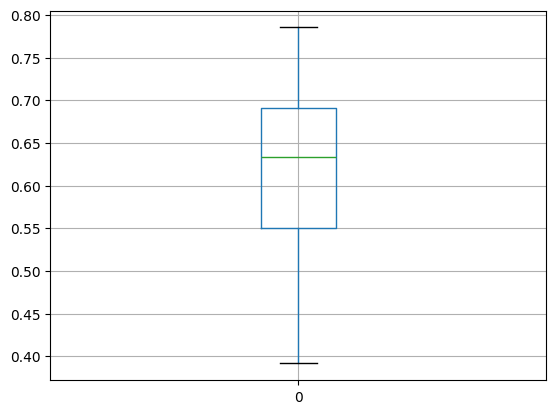

In [38]:
human_text_llm_text_sim=calculate_and_show_similarity(
    # Descrizioni prodotte dagli umani
    [meme_entry["clip_embedding"].squeeze(0) for meme_entry in data],
    # Descrizioni prodotte dal LLM
    [meme_entry["enriched_meme"].text_embedding.squeeze(0) for meme_entry in data],
    "human_text_llm_text",
)

human_text_img  mean  0.34500656
human_text_img  std  0.045986418


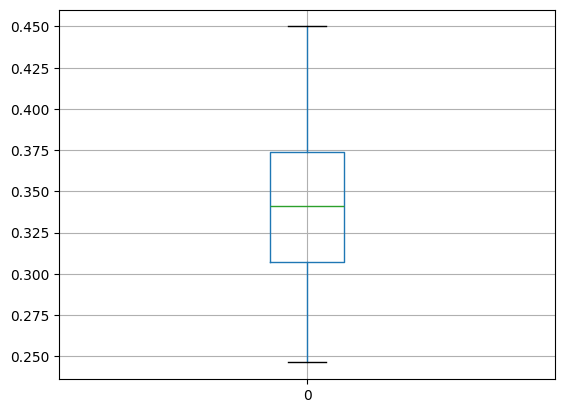

In [39]:
human_text_img_sim = calculate_and_show_similarity(
    # Descrizioni prodotte dagli umani
    [meme_entry["clip_embedding"].squeeze(0) for meme_entry in data],
    # Embedding dell'immagine
    [meme_entry["enriched_meme"].image_embedding.squeeze(0) for meme_entry in data],
    "human_text_img",
)

llm_text_img  mean  0.400821
llm_text_img  std  0.045924954


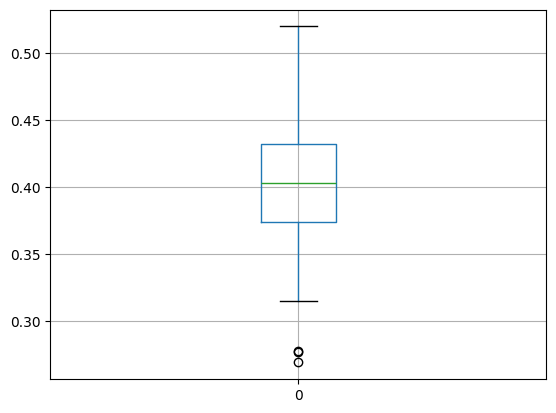

In [40]:
llm_text_img_sim=calculate_and_show_similarity(
    # Descrizioni prodotte dal LLM
    [meme_entry["enriched_meme"].text_embedding.squeeze(0) for meme_entry in data],
    # Embedding dell'immagine
    [meme_entry["enriched_meme"].image_embedding.squeeze(0) for meme_entry in data],
    "llm_text_img",
)

In [41]:
type(human_text_img_sim)

numpy.ndarray

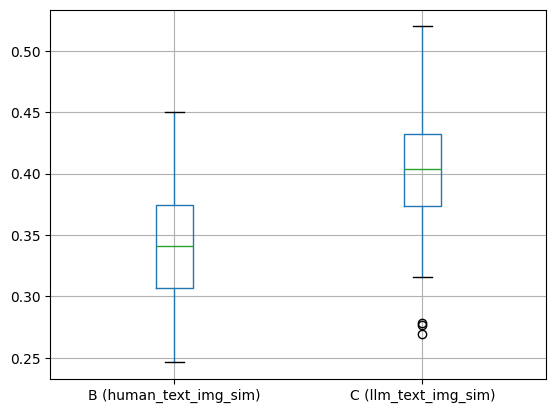

In [53]:
sim_df = pd.DataFrame()
sim_df["human_text_img_sim"] = human_text_img_sim
sim_df["llm_text_img_sim"] = llm_text_img_sim

import matplotlib.pyplot as plt

ax = sim_df.boxplot()
ax.set_xticklabels(
    [
        "B (human_text_img_sim)",
        "C (llm_text_img_sim)",
    ]
)
plt.show()